<a href="https://colab.research.google.com/github/BartolomeoML/Lesson_12/blob/main/Lesson_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
'''
Загрузка датасета, описание колонок, базовая статистика
'''

import pandas as pd
import numpy as np

# Загружаем датасет
df = pd.read_csv("https://raw.githubusercontent.com/BartolomeoML/Lesson_12/refs/heads/main/london_merged.csv")

# Выведем размерность данных и первые 5 строк
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} колонок.\n")
display(df.head())

# Проверим типы данных и наличие пропущенных значений
print("\nТипы данных и количество ненулевых значений:")
df.info()

print("\nКоличество пропущенных значений по каждой колонке:")
print(df.isnull().sum())

# Преобразуем строковый timestamp в формат datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Выведем диапазон дат в датасете
min_date = df['timestamp'].min()
max_date = df['timestamp'].max()
print(f"\nДанные собраны за период: с {min_date} по {max_date}")

'''
Базовое статистическое описание числовых признаков:
 - mean - среднее арифметическое значений
 - 25, 50, 75% - перцентили (квартили), показывающие значение, ниже которого находятся сответственно 25, 50, 75% всех значений
 - std - среднеквадратичное отклонение. Показывает, насколько сильно значения в колонке разбросаны относительно среднего.
Маленькое std означает, что данные стабильны и кучкуются близко к среднему. Большое std показывает высокую изменчивость данных
'''
df.describe()



Размерность датасета: 17414 строк, 10 колонок.



,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0



Типы данных и количество ненулевых значений:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB

Количество пропущенных значений по каждой колонке:
timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Данные собраны за пер

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,2016-01-03 22:31:00.571953664,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
min,2015-01-04 00:00:00,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2015-07-04 20:15:00,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,2016-01-03 15:30:00,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,2016-07-04 15:45:00,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,2017-01-03 23:00:00,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000
std,NaN,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911


## Интерпретация значений mean/std

Значение **mean** для **timestamp** равное `2016-01-03` находится посередине двухлетнего отрезка, что соответствует периоду датасета с 2015-01-04 00:00:00 по 2017-01-03 23:00:00 и указыват на равномерный сбор данных.

#### Группа 1. Численные показатели с высокой изменчивостью (Высокое `std`)
*   **`cnt` (Спрос):** `mean` = 1143.10, `std` = 1085.11

Отклонение практически равно среднему значению. Это значит, что спрос на велосипеды в Лондоне очень нестабилен и колеблется в огромных пределах. В среднем арендуют 1143 велосипеда в час, но из-за `std = 1085` нормальным является разброс от 58 (ночью) до 2228 (в час пик). Прогнозирование сильно зависит от времени суток.

Высокое значение std у целевого признака cnt математически показывает, что нам необходимы сложные алгоритмы (такие как XGBoost и LSTM), способные улавливать резкие колебания данных, поскольку простые линейные модели или константные предсказания на таком ряду будут сильно ошибаться.

#### Группа 2. Численные показатели с умеренной изменчивостью (Среднее `std`)
*   **`t1` и `t2` (Температура)**
    *   `t1` (реальная): `mean` = 12.47, `std` = 5.57
    *   `t2` (ощущаемая): `mean` = 11.52, `std` = 6.62
*   **`hum` (Влажность)** `mean` = 72.32, `std` = 14.31
*   **`wind_speed` (Скорость ветра)** `mean` = 15.91, `std` = 7.89

Показатели соответствуют среднестатистическим погодным показателям Лондона.

#### Группа 3. Категориальные и бинарные признаки (`std` не имеет физического смысла)
Для колонок `weather_code`, `is_holiday`, `is_weekend` и `season` рассчитывать `mean` и `std` математически можно, но физического смысла они не имеют, так как эти числа являются лишь кодами категорий.
*   **`weather_code`:** `mean` = 2.72, `std` = 2.34 (1 - ясно, 2 - облачно, 3 - пасмурно и т.д.)
*   **`is_holiday`:** `mean` = 0.022. `mean` показывает, что праздничные дни составляют **2.2%** от всей выборки, и говорит о дисбалансе классов
*   **`is_weekend`:** `mean` = 0.285. Выходные дни занимают **28.5%** времени, что говорит о данных, собраных без перекосов по дням недели
*   **`season`:** `mean` = 1.49, `std` = 1.11. Значения сезонов закодированы от 0 до 3. Среднее около 1.5 доказывает, что все 4 сезона представлены в выборке примерно в равных долях.

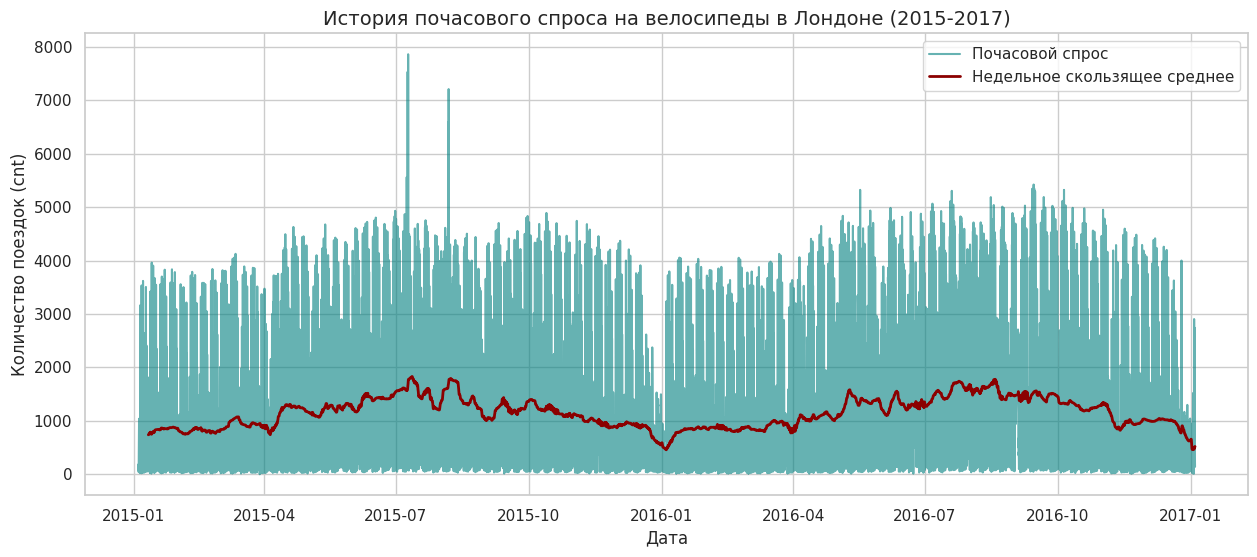

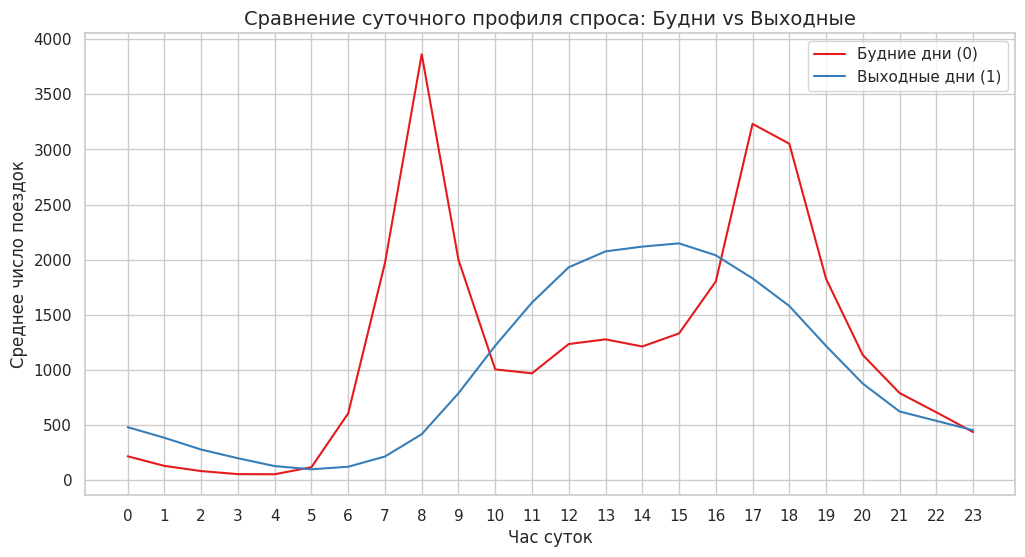

In [4]:
'''
Визуализация датасета
'''

import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['cnt'], color='teal', alpha=0.6, label='Почасовой спрос')
plt.title('История почасового спроса на велосипеды в Лондоне (2015-2017)', fontsize=14)

'''
Сглаженный график (скользящее среднее за неделю — 168 часов) для выявления тренда (rolling(168).mean())
Для каждой конкретной строки (например, для 12:00 сегодняшнего дня) алгоритм берет значение cnt за этот час и за предыдущие 167 часов (суммарно за неделю).
Для первых 167 часов датасета скользящее среднее рассчитать невозможно (т.к. нет истории за неделю). Поэтому первые 167 точек будут иметь значение NaN, и линия на графике начнется только со второй недели наблюдений
'''
plt.plot(df['timestamp'], df['cnt'].rolling(168).mean(), color='darkred', linewidth=2, label='Недельное скользящее среднее')
plt.xlabel('Дата')
plt.ylabel('Количество поездок (cnt)')
plt.legend()
plt.show()

# Временные признаки для анализа
eda_df = df.copy()
eda_df['hour'] = eda_df['timestamp'].dt.hour
eda_df['day_of_week'] = eda_df['timestamp'].dt.day_name()

plt.figure(figsize=(12, 6))
sns.lineplot(data=eda_df, x='hour', y='cnt', hue='is_weekend', estimator='mean', errorbar=None, palette='Set1')
plt.title('Сравнение суточного профиля спроса: Будни vs Выходные', fontsize=14)
plt.xlabel('Час суток')
plt.ylabel('Среднее число поездок')
plt.xticks(range(0, 24))
plt.legend(['Будние дни (0)', 'Выходные дни (1)'])
plt.show()

In [5]:
'''
Создание признаков, разбиение и масштабирование
'''

from sklearn.preprocessing import StandardScaler

# Создаем копию данных с сортировкой по временнЫм меткам
df_prep = df.copy().sort_values('timestamp').reset_index(drop=True)

# Выделяем базовые компоненты времени
df_prep['hour'] = df_prep['timestamp'].dt.hour
df_prep['month'] = df_prep['timestamp'].dt.month
df_prep['day_of_week'] = df_prep['timestamp'].dt.dayofweek

# Циклическое кодирование (sin/cos), чтобы модель понимала близость 23:00 и 00:00
'''
Стандартные модели машинного обучения (деревья, линейные модели) воспринимают числа линейно: 0<1<2<...<22<23.
Для модели разница между 23:00 и 00:00 часами математически равна 23−0=23, также и с переходом между 31 декабря и 1 января.
С помощью тригонометрии (синуса и косинуса) часы проецируются на единичный круг, на котором точка 23:00 и точка 00:00 будут
находиться вплотную друг к другу в двухмерных координатах
'''
df_prep['hour_sin'] = np.sin(2 * np.pi * df_prep['hour'] / 24.0)
df_prep['hour_cos'] = np.cos(2 * np.pi * df_prep['hour'] / 24.0)
df_prep['month_sin'] = np.sin(2 * np.pi * df_prep['month'] / 12.0)
df_prep['month_cos'] = np.cos(2 * np.pi * df_prep['month'] / 12.0)

# Генерация лагов (значений спроса в прошлом)
'''
cnt_lag_1 — это спрос в предыдущий час
cnt_lag_24 — это спрос в этот же час вчера
Лаг на  1 час говорит модели, что если час назад (в 8:00) спрос был огромным, то в 9:00 он, скорее всего, останется высоким
Лаг на 24 часа дает модели понимание суточного ритма (если вчера в 18:00 был час пик, то и сегодня в 18:00 с большой вероятностью будет час пик)
Лаг на 2 часа помогает понимать динамику движения и направление тренда, а также прохождение пика
'''
df_prep['cnt_lag_1'] = df_prep['cnt'].shift(1)
df_prep['cnt_lag_2'] = df_prep['cnt'].shift(2)
df_prep['cnt_lag_24'] = df_prep['cnt'].shift(24)

# Удаляем строки с NaN, которые образовались из-за использования лагов (пожертвовали первыми 24 строками (первыми сутками))
df_prep = df_prep.dropna().reset_index(drop=True)

# Разделение признаков на таргет (y) и фичи (X). Убираем нечисловые и исходные колонки времени
features = [
    't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'cnt_lag_1', 'cnt_lag_2', 'cnt_lag_24'
]
X = df_prep[features]
y = df_prep['cnt']

# Хронологический сплит (Train - 80%, Test - 20%)
train_size = int(len(df_prep) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Сохраняем для графика на оси X значения timestamp в исходном формате для наглядности, вместо указания там номера строки
test_timestamps = df_prep['timestamp'].iloc[train_size:]

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Превратим обратно в DataFrame с возвратом исходных имён колонок для удобства чтения графиков
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print(f"Обучающая выборка (X_train): {X_train_scaled.shape}")
print(f"Тестовая выборка (X_test): {X_test_scaled.shape}")

Обучающая выборка (X_train): (13912, 15)
Тестовая выборка (X_test): (3478, 15)


In [6]:
'''
Создание словаря для сбора метрик качества всех моделей
'''

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Словарь для сохранения метрик моделей
metrics_summary = {}

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100 # в процентах

    metrics_summary[model_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE %': mape}
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

In [7]:
'''
Обучение и прогноз SARIMAX
'''

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

'''
Загрузка данных для обучения. Работаем с копией датафрейма для защиты от изменения исходных данных.

Во временных рядах есть два типа переменных:
- Эндогенная (Endogenous): это наш таргет cnt (спрос). Мы прогнозируем его на основе его же прошлых значений (авторегрессия);
- Экзогенные (Exogenous): это внешние факторы, которые влияют на спрос, но сам спрос на них повлиять не может.

Используем экзогенные признаки 't1', 'hum', 'is_holiday', 'is_weekend'.

Модели SARIMAX не нужны лаги в качестве внешних признаков, потому что она сама умеет строить авторегрессию
(находить связи с прошлым) на основе математических параметров order и seasonal_order. Передача лагов и
тригонометрического времени в exog привела бы к избыточности данных (мультиколлинеарности),
из-за чего модель просто не смогла бы сойтись при обучении
'''
sarimax_train_y = y_train.copy()
sarimax_train_exog = X_train_scaled[['t1', 'hum', 'is_holiday', 'is_weekend']].copy()

print("Запуск обучения базовой модели SARIMAX...")

model_sarimax = sm.tsa.statespace.SARIMAX(
    sarimax_train_y, # одномерный целевой ряд (история спроса cnt)
    exog=sarimax_train_exog, # таблица с внешними факторами. Модель учится сопоставлять погоду со спросом

    # Параметры несезонной части ARIMA (order=(p, d, q) = (1, 1, 1)):
    # p=1 (Autoregressive - AR): Модель учитывает значение ровно 1 час назад
    # d=1 (Integrated - I): Модель берет первые разности ряда. Это нужно, чтобы привести временной ряд к стационарному виду (убрать глобальный тренд)
    # q=1 (Moving Average - MA): Модель учитывает ошибку предыдущего прогноза (с лагом 1) для корректировки текущего значения
    order=(1, 1, 1),

    # Параметры сезонной части ARIMA (seasonal_order=(P, D, Q, s) = (1, 0, 0, 24)):
    # P=1: Сезонная авторегрессия. Модель учитывает значение ряда ровно 24 часа назад (суточный цикл)
    # D=1: Сезонное дифференцирование (можно отключать для ускорения вычисления)
    # Q=0: Сезонное скользящее среднее (можно отключать для ускорения вычисления)
    # s=24: Период сезонности. Так как данные почасовые, а основной цикл спроса в городе суточный, мы задаем период в 24 часа.
    seasonal_order=(1, 1, 0, 24),

    # enforce_stationarity=False и enforce_invertibility=False - технические флаги оптимизатора.
    # По умолчанию алгоритм проверяет, лежат ли коэффициенты модели в строгих математических границах стационарности.
    # Установка False отключает эти жесткие проверки. Это ускоряет обучение и предотвращает частые ошибки сходимости (ConvergenceWarning).
    # Данные параметры не влияют на точность напрямую
    enforce_stationarity=False,
    enforce_invertibility=False
)

'''
Эксперименты по проверке скорости работы и полученным метрикам в зависимости от состояний параметров D и Q:

seasonal_order=(1, 0, 0, 24) (длительность: 15-30 секунд):
MAE: 250.30
RMSE: 444.00
MAPE: 39.13%

seasonal_order=(1, 1, 0, 24) (длительность: пара минут):
MAE: 233.40
RMSE: 449.59
MAPE: 37.14%

seasonal_order=(1, 1, 1, 24) (длительность: 10-15 минут):
MAE: 238.16
RMSE: 421.52
MAPE: 37.15%

Принято решение оставить seasonal_order=(1, 1, 0, 24) как компромисс между скоростью и точностью
'''

results_sarimax = model_sarimax.fit(disp=False)

print("Расчёт прогнозов...")

'''
Индексы строк тестовой целевой переменной y_test (числа от 13912 до 17389) принудительно копируются в таблицу
тестовых погодных признаков sarimax_test_exog. Из-за масштабирования (масштабатор возвращает чистый NumPy-массив)
индексы погоды сбросились в диапазон 0..3477. Математический аппарат statsmodels строго требует, чтобы погода и спрос
шли по одной временной шкале шаг за шагом. Синхронизация индексов убирает ошибку несовместимости шкал.

Выравниваем индексы тестовых внешних признаков (exog) с целевой переменной y_test
'''
sarimax_test_exog = X_test_scaled[['t1', 'hum', 'is_holiday', 'is_weekend']].copy()
sarimax_test_exog.index = y_test.index  # восстанавливаем индексы для statsmodels

'''
SARIMAX в библиотеке statsmodels реализована в пространстве состояний и под капотом у неё работает фильтр Калмана.

Вместо долгого переобучения модели на тестовом периоде, используется метод .append(refit=False),
который применяет ранее обученные коэффициенты и запускает фильтр Калмана по тестовой выборке,
считывающий реальную историю (какой спрос был час назад на самом деле), что позволяет быстро рассчитать
честные одношаговые прогнозы (One-Step-Ahead predictions) на несколько месяцев вперед
'''
res_appended = results_sarimax.append(
    y_test,
    exog=sarimax_test_exog,
    refit=False
)

# Извлекаем одношаговые прогнозы для тестового периода (len(y_test) == 3478)
sarimax_pred = res_appended.fittedvalues.iloc[-len(y_test):]
sarimax_pred = np.clip(sarimax_pred, 0, None)

# Оцениваем модель
evaluate_model('SARIMAX', y_test, sarimax_pred)

Запуск обучения базовой модели SARIMAX...
Расчёт прогнозов...
--- SARIMAX ---
MAE: 233.40
RMSE: 449.59
MAPE: 37.14%


In [8]:
'''
Ансамбль деревьев — Random Forest Regressor
'''

from sklearn.ensemble import RandomForestRegressor

print("Запуск обучения Random Forest...")

# Инициализируем модель с базовыми параметрами
'''
«При инициализации Random Forest зафиксировали random_state=42 для воспроизводимости результатов,
распараллелили вычисления на все ядра процессора с помощью n_jobs=-1 и применили базовое количество деревьев n_estimators=100.
Главным регуляризатором выступило ограничение глубины деревьев max_depth=12, что позволяет модели уловить сложные нелинейные зависимости в данных, избежав при этом переобучения»
'''
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Прогноз
rf_pred = rf_model.predict(X_test_scaled)
rf_pred = np.clip(rf_pred, 0, None)

# Оцениваем модель
evaluate_model('Random Forest', y_test, rf_pred)

Запуск обучения Random Forest...
--- Random Forest ---
MAE: 100.70
RMSE: 182.39
MAPE: 12.43%


In [9]:
'''
Градиентный бустинг — XGBoost
'''

from xgboost import XGBRegressor

print("Запуск обучения XGBoost...")

# Инициализируем модель с базовыми параметрами
'''
В отличие от Random Forest, где использовались глубокие параллельные деревья (max_depth=12), в XGBoost применяется концепция бустинга над слабыми учениками
с ограничением глубины деревьев значением 6 (деревья строятся последовательно друг за другом и каждое новое дерево обучается на ошибках (остатках) предыдущих, постепенно исправляя их).
Чтобы предотвратить переобучение при последовательном исправлении ошибок в течение 150 шагов, замедляем скорость обучения
(learning_rate=0.05 - коэффициент, на который умножается вклад каждого нового дерева), снизив вклад каждого отдельного дерева до 5%
'''
xgb_model = XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)

# Прогноз
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred = np.clip(xgb_pred, 0, None)

# Оцениваем модель
evaluate_model('XGBoost', y_test, xgb_pred)

Запуск обучения XGBoost...
--- XGBoost ---
MAE: 103.32
RMSE: 185.45
MAPE: 14.05%


In [10]:
'''
Обучение и прогноз LSTM
'''

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Изменение размерности данных под формат LSTM: (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_scaled.values, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled.values, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Создание архитектуры нейросети LSTM
'''
Класс Sequential указывает Keras, что слои нейросети будут идти последовательно, один за другим.

'''
lstm_model = Sequential([
    # - LSTM: Специализированный рекуррентный слой. Он содержит внутренние ячейки памяти и «ворота» (gates), которые позволяют нейросети запоминать информацию во времени и отбрасывать ненужный шум.
    # - 64: Количество нейронов (ячеек памяти) в этом слое. Оно определяет сложность и богатство признаков, которые слой сможет извлечь.
    # - activation='relu'. Используем её вместо стандартной для LSTM функции tanh, так как ReLU обучается быстрее, помогает избежать проблемы затухания градиентов и отлично подходит для сугубо положительных чисел спроса.
    # - input_shape: Формат входных данных (timesteps, features). Поскольку мы заранее сгенерировали лаги (lag_1, lag_24) внутри строк таблицы, длина нашей последовательности во времени (timesteps) равна 1,
    # а количество признаков (features) равно 15. Это стандартный способ подать табличные временные ряды в LSTM.
    # - return_sequences=True: важный параметр. Он заставляет первый слой LSTM возвращать всю последовательность выходов, а не только последний элемент. Это обязательно нужно указывать, если ставить один слой LSTM сразу за другим.
    # Без этого параметра второй слой LSTM не сможет принять данные и выдаст ошибку.
    LSTM(64, activation='relu', input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),

    # Dropout: Слой регуляризации (прореживания). Во время обучения он случайным образом «выключает» 20% нейронов на каждом шаге. Это заставляет нейросеть не полагаться на какой-то один признак, а распределять знания по всей сети.
    Dropout(0.2),

    # LSTM(32): Второй рекуррентный слой с 32 нейронами. Здесь параметр return_sequences равен False. Это значит, что слой сжимает временную последовательность и выдает плоский двумерный вектор размерностью 32, готовый для передачи в классические полносвязные слои.
    LSTM(32, activation='relu'),
    Dropout(0.2),

    # Dense(16): Классический полносвязный (Dense) слой с 16 нейронами. Он агрегирует 32 выхода из LSTM и обобщает их в 16 высокоуровневых абстрактных признаков.
    Dense(16, activation='relu'),

    # Dense(1): Выходной слой. В нем ровно 1 нейрон, так как мы решаем задачу регрессии (прогнозируем одно конкретное число — спрос в часах). Здесь нет функции активации (по умолчанию она линейная), чтобы нейросеть могла выдавать любые непрерывные численные значения.
    Dense(1)
])

# Компиляция модели
'''
optimizer='adam': оптимизатор Adam (Adaptive Moment Estimation), который автоматически и динамически адаптирует шаг обучения (learning rate) для каждого веса нейросети в отдельности, делая сходимость быстрой и стабильной.
loss='mse': функция потерь — среднеквадратичная ошибка (Mean Squared Error). Это то, что нейросеть пытается минимизировать в процессе обучения. MSE жестко наказывает сеть за крупные промахи, что отлично согласуется с метрикой RMSE.
metrics=['mae']: метрика, за которой следим в реальном времени во время обучения (средняя абсолютная ошибка в штуках велосипедов).
'''
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Ранняя остановка, чтобы нейросеть не переобучалась
'''
monitor='val_loss': следит за ошибкой на валидационной (незнакомой для сети) выборке.
patience=5: «терпение» модели. Если в течение 5 эпох подряд ошибка на валидации не уменьшается, процесс обучения автоматически прерывается.
restore_best_weights=True: когда обучение остановится, библиотека автоматически вернет веса нейросети на ту эпоху, где ошибка на валидации была минимальной (а не оставит веса последней, переобученной эпохи).
'''
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Запуск обучения LSTM нейросети...")

# Запуск обучения
'''
epochs=40: максимальное количество полных проходов нейросети по всему обучающему датасету. Благодаря EarlyStopping модель, скорее всего, остановится раньше (например, на 15–20 эпохе), не доходя до 40.
batch_size=64: размер пакета данных. Нейросеть обучается на пакетах из 64 строк, считает по ним ошибку, обновляет свои веса, затем берет следующие 64 строки. 64 — это стандартный баланс между скоростью расчетов и стабильностью градиента.
validation_split=0.1: нейросеть берет 10% обучающих данных (около 1390 строк) и откладывает их в сторону, не обучаясь на них. В конце каждой эпохи она проверяет свою точность на этих 10%, чтобы рассчитать val_loss и понять, не началось ли переобучение.
callbacks=[early_stop]: подключает ранее созданный триггер ранней остановки.
verbose=1: включает интерактивный прогресс-бар в консоли Colab, для визуализации процесса обучения по каждой эпохе.
'''
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Прогноз
lstm_pred = lstm_model.predict(X_test_lstm).flatten()
lstm_pred = np.clip(lstm_pred, 0, None)

# Оцениваем модель
evaluate_model('LSTM', y_test, lstm_pred)

Запуск обучения LSTM нейросети...
Epoch 1/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1958521.7500 - mae: 990.4586 - val_loss: 722370.0625 - val_mae: 542.3780
Epoch 2/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 538377.0625 - mae: 480.3468 - val_loss: 442925.7500 - val_mae: 441.3168
Epoch 3/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 321536.4375 - mae: 376.4908 - val_loss: 329661.4375 - val_mae: 364.3599
Epoch 4/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 279526.2812 - mae: 339.4003 - val_loss: 295277.3438 - val_mae: 344.1265
Epoch 5/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 246526.0312 - mae: 317.4434 - val_loss: 272670.0000 - val_mae: 332.3715
Epoch 6/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 227254.6406 - mae: 301.5244 - val_loss: 237525.1719 - val_mae: 315.5728
Epoch 7/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 213011.3906 - mae: 291.0650 - val_loss: 220531.5469 - val_mae: 297.2928
Epoch 8/40
196/196 ━━━━━━━━━━━━━━━━━━━━ 1

In [12]:
!pip install pycaret --pre -U --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.39.0 which is incompatible.


In [13]:
'''
AutoML (PyCaret)
'''

from pycaret.regression import RegressionExperiment
from IPython.display import display

# Глушим логирование lightgbm, чтобы не засорять консоль
import lightgbm as lgb
# Создаем пустой логгер, который будет игнорировать все сообщения LightGBM
class SilentLGBMLogger:
    def info(self, message): pass
    def warning(self, message): pass
    def error(self, message): pass
# Регистрируем наш логгер в системе LightGBM
lgb.register_logger(SilentLGBMLogger())

# Подготавливаем тренировочный датасет (признаки + таргет)
pycaret_train = X_train_scaled.copy()
pycaret_train['cnt'] = y_train.values

# Инициализируем объект эксперимента PyCaret 4.0
exp = RegressionExperiment(
    target='cnt',
    session_id=42,
    preprocess=False
)

# Обучаем эксперимент только на тренировочных данных
exp.fit(pycaret_train)

# Запускаем автоматическое сравнение всех моделей
print("Запуск сравнения моделей...")
compare_result = exp.compare_models()

# Выводим таблицу сравнения моделей с метриками
print("---Таблица сравнения моделей---:")
display(exp.pull()) # Забирает и отрисовывает итоговую таблицу сравнения

# Извлекаем лучшую модель
best_automl_model = compare_result.best

# Выводим информацию о лучшей модели и её гиперпараметрах
print("---Лучшая модель---:")
print(best_automl_model)

Запуск сравнения моделей...
---Таблица сравнения моделей---:


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,et,81.0895,2.229017e+04,148.6372,0.9802,0.1815,0.0
1,lightgbm,93.0144,2.693452e+04,163.6234,0.9762,0.2171,0.0
2,xgboost,95.6898,2.898249e+04,169.9645,0.9743,0.2068,0.0
3,rf,95.1892,3.339417e+04,182.2598,0.9705,0.1920,0.0
4,gbr,138.3701,5.103196e+04,225.4275,0.9548,0.3466,0.0
5,dt,135.6638,7.086648e+04,265.0325,0.9373,0.2633,0.0
6,knn,160.6294,8.770780e+04,295.2541,0.9221,0.3471,0.0
7,ada,376.1122,1.922672e+05,438.1285,0.8299,0.9201,0.0
8,ard,293.6916,2.180543e+05,466.6250,0.8074,0.6138,0.0
9,ridge,294.0748,2.180976e+05,466.6729,0.8074,0.6141,0.0


---Лучшая модель---:
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['t1', 't2', 'hum',
                                                   'wind_speed', 'weather_code',
                                                   'is_holiday', 'is_weekend',
                                                   'season', 'hour_sin',
                                                   'hour_cos', 'month_sin',
                                                   'month_cos', 'cnt_lag_1',
                                                   'cnt_lag_2',
                                                   'cnt_lag_24'])],
                                   verbose_feature_names_out=False)),
                ('et', ExtraTreesRegressor(n_jobs=-1, random_state=42))])


In [14]:
'''
Прогноз и оценка AutoML на тестовой выборке
'''

# Создаем тестовый датасет для PyCaret
pycaret_test = X_test_scaled.copy()
pycaret_test['cnt'] = y_test.values

# Делаем прогноз лучшей AutoML моделью на независимых тестовых данных
predict_result = exp.predict_model(best_automl_model, data=pycaret_test)

# Извлекаем предсказанные значения из столбца 'prediction_label'
y_pred_automl = predict_result.predictions['prediction_label'].values
y_pred_automl = np.clip(y_pred_automl, 0, None)

# Оцениваем модель
evaluate_model('AutoML (PyCaret)', y_test, y_pred_automl)

--- AutoML (PyCaret) ---
MAE: 93.43
RMSE: 163.32
MAPE: 12.47%


Анализ порогов нормальности:
Порог -0.20 | Точек:    3 | Процент: 0.02%
Порог -0.19 | Точек:    7 | Процент: 0.04%
Порог -0.18 | Точек:   15 | Процент: 0.09%
Порог -0.15 | Точек:   65 | Процент: 0.37%
Порог -0.14 | Точек:   96 | Процент: 0.55%
Порог -0.13 | Точек:  139 | Процент: 0.80%
Порог -0.12 | Точек:  196 | Процент: 1.13%
Порог -0.11 | Точек:  282 | Процент: 1.62%
Порог -0.10 | Точек:  380 | Процент: 2.19%
Порог -0.09 | Точек:  491 | Процент: 2.82%
Порог -0.08 | Точек:  656 | Процент: 3.77%
Порог -0.07 | Точек:  859 | Процент: 4.94%
Порог -0.06 | Точек: 1106 | Процент: 6.36%
Порог -0.05 | Точек: 1422 | Процент: 8.18%
Порог +0.00 | Точек: 3821 | Процент: 21.97%


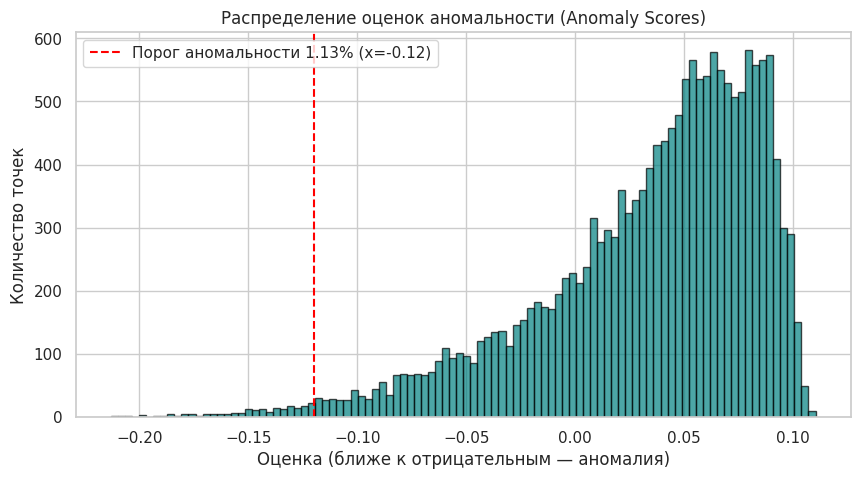

In [38]:
'''
Поиск числового значения количества аномалий (в процентах) для дальнейшей работы с Isolation Forest
'''

import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Выделяем признаки для анализа аномалий
anomaly_features = ['cnt', 't1', 'hum', 'wind_speed']
X_anomaly = df_prep[anomaly_features]

# Инициализируем и обучаем временный Изолирующий лес
iso_forest_temp = IsolationForest(random_state=42)
iso_forest_temp.fit(X_anomaly)

# Рассчитываем оценки аномальности
scores = iso_forest_temp.decision_function(X_anomaly)

# Прогоняем цикл по порогам
print("Анализ порогов нормальности:")
for temp_threshold in [-0.20, -0.19, -0.18, -0.15, -0.14, -0.13, -0.12, -0.11, -0.10, -0.09, -0.08, -0.07, -0.06, -0.05, 0.0]:
    count = (scores < temp_threshold).sum()
    pct = (count / len(scores)) * 100
    print(f"Порог {temp_threshold:+.2f} | Точек: {count:4d} | Процент: {pct:.2f}%")

# Отрисовываем гистограмму распределения оценок
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=100, color='teal', edgecolor='black', alpha=0.7)

plt.axvline(x=-0.12, color='red', linestyle='--', label='Порог аномальности 1.13% (x=-0.12)')

plt.title('Распределение оценок аномальности (Anomaly Scores)')
plt.xlabel('Оценка (ближе к отрицательным — аномалия)')
plt.ylabel('Количество точек')
plt.legend()
plt.show()


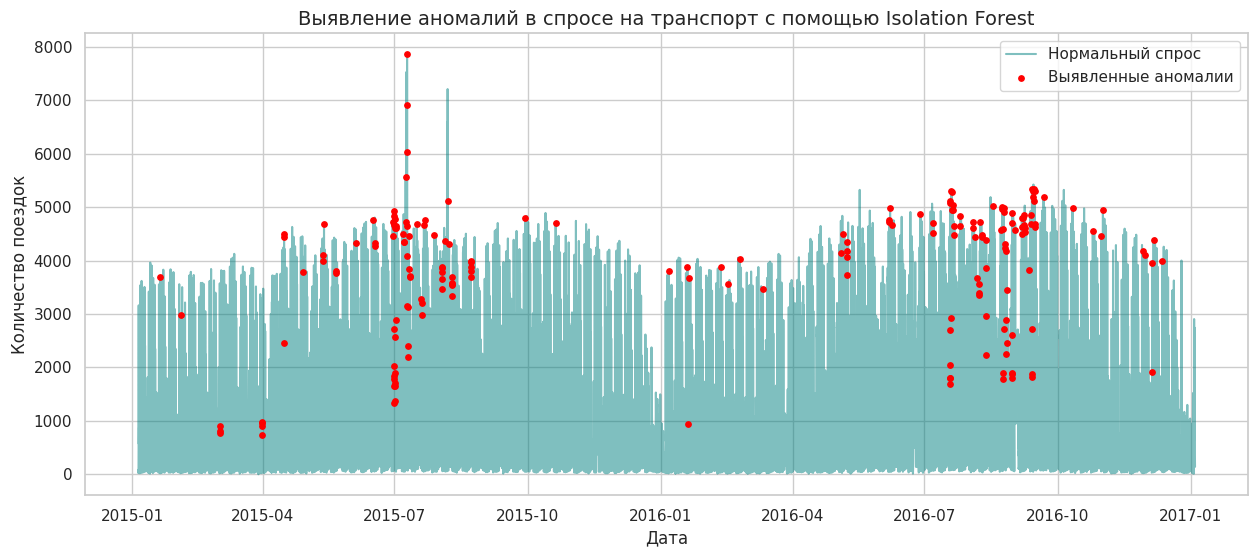

Выявлено аномальных точек: 197 из 17390


In [39]:
'''
Поиск аномалий с помощью Isolation Forest и их визуализация
'''

from sklearn.ensemble import IsolationForest

# Выбираем признаки для поиска аномалий
anomaly_features = ['cnt', 't1', 'hum', 'wind_speed']
X_anomaly = df_prep[anomaly_features]

# Инициализируем модель
'''
На графике прослеживается несколько ступеней в хвосте распределения аномалий. Выберем порог -0.12 (1.13%), чтобы не исключать естественную неестественность и вариативность в поведении людей для обучения модели
'''
iso_forest = IsolationForest(contamination=0.0113, random_state=42)
df_prep['anomaly'] = iso_forest.fit_predict(X_anomaly)

# Isolation Forest возвращает -1 для аномалий и 1 для нормальных данных
anomalies = df_prep[df_prep['anomaly'] == -1]

# Визуализация аномалий на графике спроса
plt.figure(figsize=(15, 6))
plt.plot(df_prep['timestamp'], df_prep['cnt'], color='teal', alpha=0.5, label='Нормальный спрос')
plt.scatter(anomalies['timestamp'], anomalies['cnt'], color='red', s=15, label='Выявленные аномалии', zorder=5)
plt.title('Выявление аномалий в спросе на транспорт с помощью Isolation Forest', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Количество поездок')
plt.legend()
plt.show()

print(f"Выявлено аномальных точек: {len(anomalies)} из {len(df_prep)}")

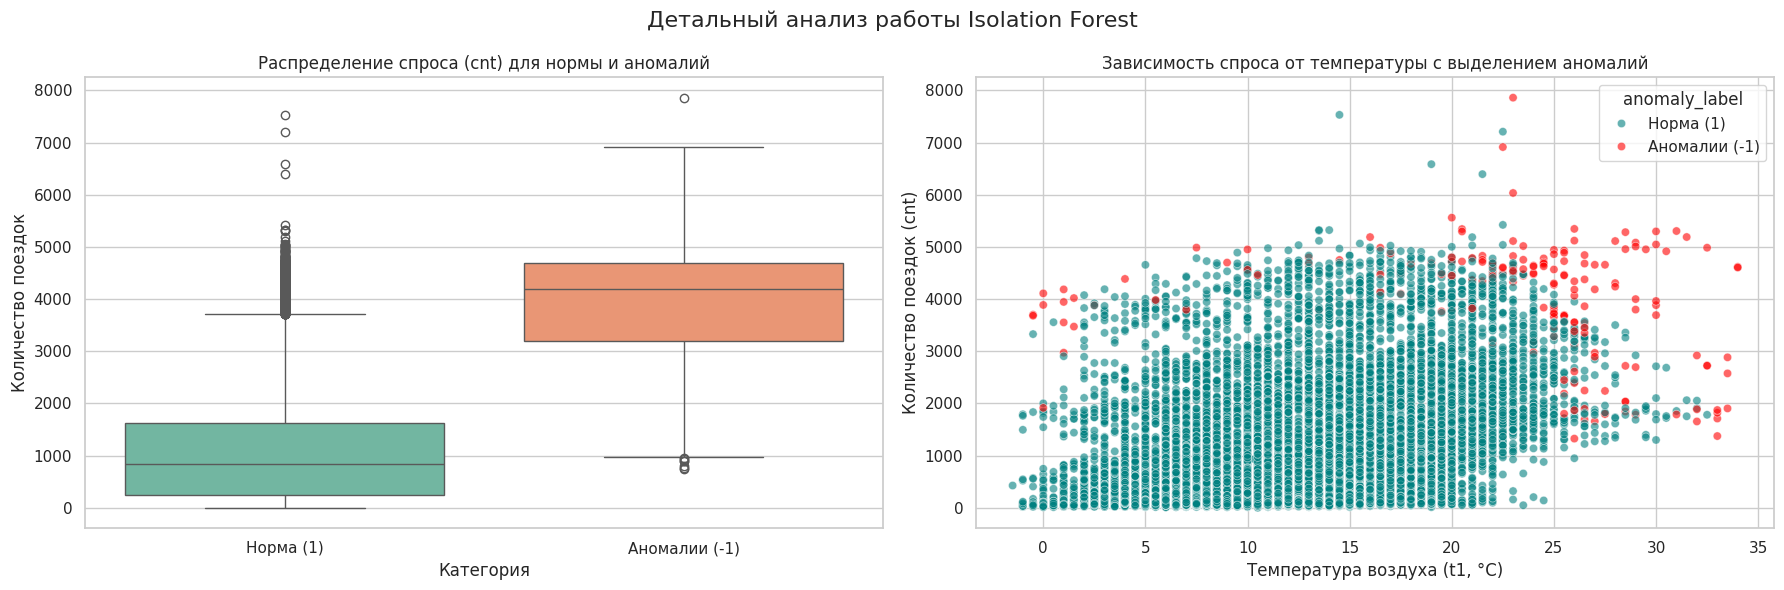

In [33]:
'''
Дополнительная визуализация аномалий: зависимость от температуры
'''

# Создаем в датафрейме текстовую колонку для подписей
df_prep['anomaly_label'] = df_prep['anomaly'].map({-1: 'Аномалии (-1)', 1: 'Норма (1)'})

# Инициализируем графики
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot - показывает распределение спроса для нормальных и аномальных дней
sns.boxplot(
    data=df_prep,
    x='anomaly_label',
    y='cnt',
    hue='anomaly_label',
    ax=axes[0],
    palette='Set2',
    legend=False
)
axes[0].set_title('Распределение спроса (cnt) для нормы и аномалий')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Количество поездок')

# Scatter plot (Температура vs Спрос) с подсветкой аномалий - показывает, в каких погодных условиях происходили аномалии
sns.scatterplot(
    data=df_prep,
    x='t1',
    y='cnt',
    hue='anomaly_label',
    ax=axes[1],
    palette={'Норма (1)': 'teal', 'Аномалии (-1)': 'red'},
    alpha=0.6
)
axes[1].set_title('Зависимость спроса от температуры с выделением аномалий')
axes[1].set_xlabel('Температура воздуха (t1, °C)')
axes[1].set_ylabel('Количество поездок (cnt)')

plt.suptitle('Детальный анализ работы Isolation Forest', fontsize=16)
plt.tight_layout()
plt.show()

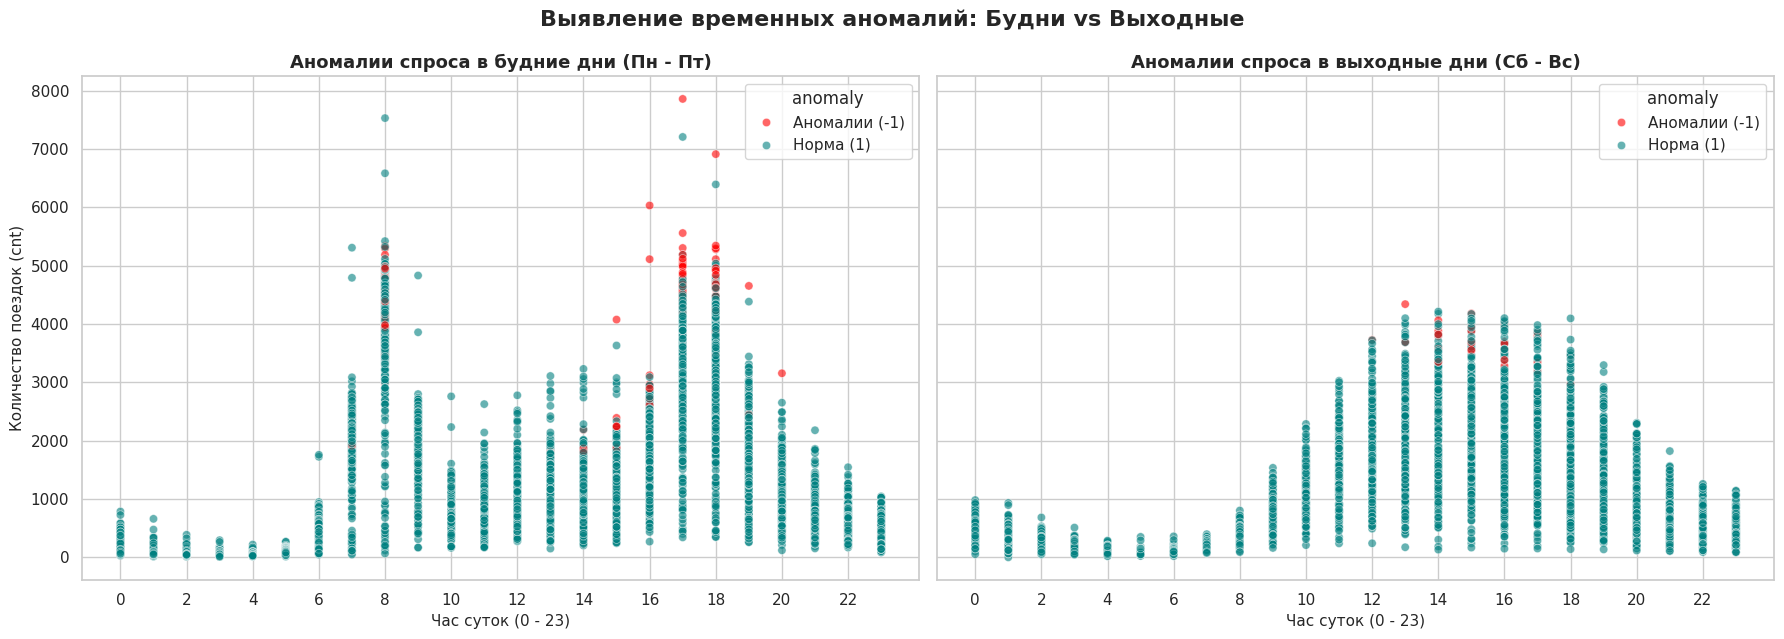

In [34]:
'''
Дополнительная визуализация аномалий: зависимость от будних/выходных дней
'''

# Убедимся, что у нас есть колонка 'hour' в датафрейме (если нет — извлечем её)
if 'hour' not in df_prep.columns:
    df_prep['hour'] = df_prep['timestamp'].dt.hour

# Создаем двухпанельный график
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), sharey=True)

# График для будних дней (is_weekend == 0)
sns.scatterplot(
    data=df_prep[df_prep['is_weekend'] == 0],
    x='hour',
    y='cnt',
    hue='anomaly',
    palette={1: 'teal', -1: 'red'},
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Аномалии спроса в будние дни (Пн - Пт)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Час суток (0 - 23)', fontsize=11)
axes[0].set_ylabel('Количество поездок (cnt)', fontsize=11)
axes[0].set_xticks(range(0, 24, 2)) # Шаг сетки по часам
axes[0].get_legend().texts[0].set_text('Аномалии (-1)')
axes[0].get_legend().texts[1].set_text('Норма (1)')

# График для выходных дней (is_weekend == 1)
sns.scatterplot(
    data=df_prep[df_prep['is_weekend'] == 1],
    x='hour',
    y='cnt',
    hue='anomaly',
    palette={1: 'teal', -1: 'red'},
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Аномалии спроса в выходные дни (Сб - Вс)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Час суток (0 - 23)', fontsize=11)
axes[1].set_ylabel('') # Убираем дублирующуюся подпись оси Y, так как график общий
axes[1].set_xticks(range(0, 24, 2))
axes[1].get_legend().texts[0].set_text('Аномалии (-1)')
axes[1].get_legend().texts[1].set_text('Норма (1)')

plt.suptitle('Выявление временных аномалий: Будни vs Выходные', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

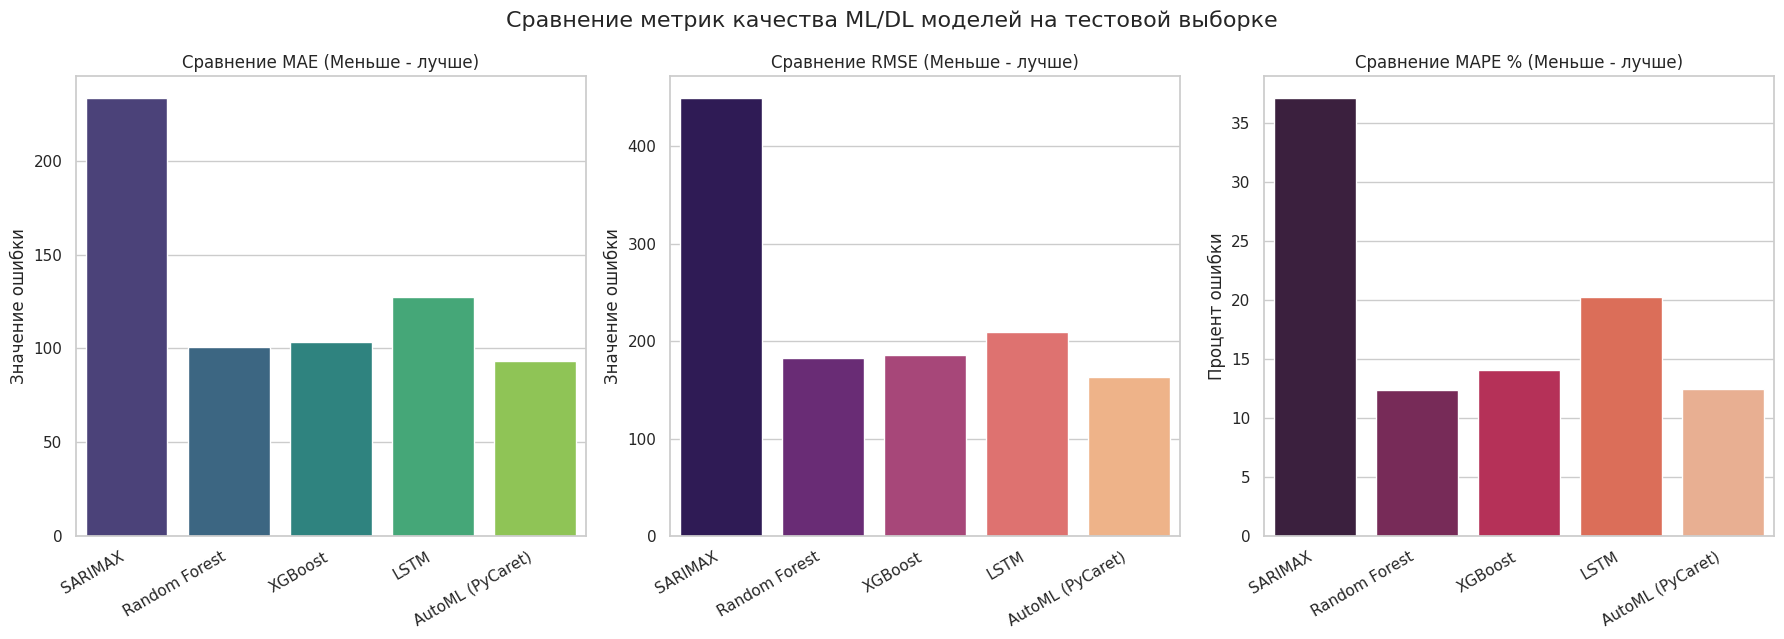

,MAE,RMSE,MAPE %
SARIMAX,233.400234,449.592413,37.144142
Random Forest,100.702990,182.390041,12.428092
XGBoost,103.318535,185.446452,14.053874
LSTM,127.438568,209.056941,20.315576
AutoML (PyCaret),93.432812,163.317913,12.474697


In [35]:
'''
Построение графиков метрик качества (MAE, RMSE, MAPE)
'''

# Преобразуем словарь метрик в DataFrame
df_metrics = pd.DataFrame(metrics_summary).T

# Увеличили высоту графика до 6.5 для размещения подписей
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

# График MAE
sns.barplot(x=df_metrics.index, y=df_metrics['MAE'], ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение MAE (Меньше - лучше)')
axes[0].set_ylabel('Значение ошибки')

# График RMSE
sns.barplot(x=df_metrics.index, y=df_metrics['RMSE'], ax=axes[1], palette='magma')
axes[1].set_title('Сравнение RMSE (Меньше - лучше)')
axes[1].set_ylabel('Значение ошибки')

# График MAPE
sns.barplot(x=df_metrics.index, y=df_metrics['MAPE %'], ax=axes[2], palette='rocket')
axes[2].set_title('Сравнение MAPE % (Меньше - лучше)')
axes[2].set_ylabel('Процент ошибки')

# Поворачиваем подписи под углом 30 градусов на каждом из трех графиков
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_xlabel("") # пустая строка для подписи оси Х

plt.suptitle('Сравнение метрик качества ML/DL моделей на тестовой выборке', fontsize=16)
plt.tight_layout() # Автоматически подгоняет поля, чтобы повернутый текст не обрезался
plt.show()

# Выведем саму таблицу метрик для проверки
df_metrics

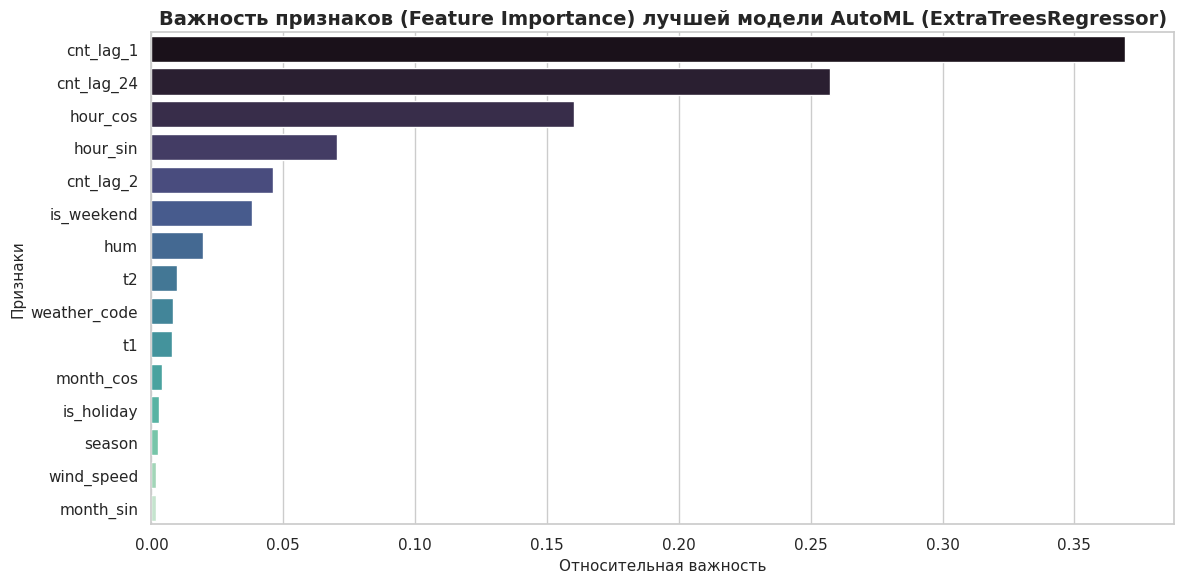

In [40]:
'''
Важность признаков для модели-победителя
'''

# Извлекаем финальный обученный алгоритм
automl_estimator = best_automl_model.steps[-1][1]

# Получаем имя класса модели
winner_model_name = automl_estimator.__class__.__name__

# Получаем важности признаков из модели-победителя
importances = automl_estimator.feature_importances_
indices = np.argsort(importances)[::-1]

# Строим график
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='mako')

plt.title(f'Важность признаков (Feature Importance) лучшей модели AutoML ({winner_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Относительная важность', fontsize=11)
plt.ylabel('Признаки', fontsize=11)
plt.tight_layout()
plt.show()

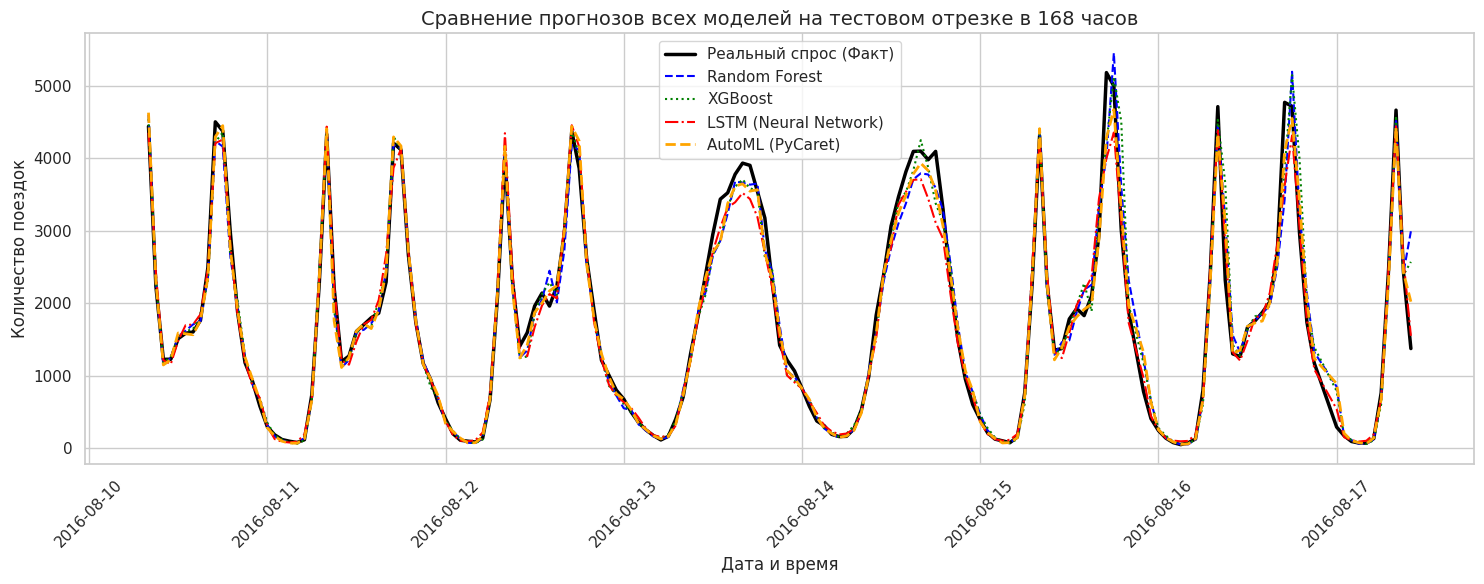

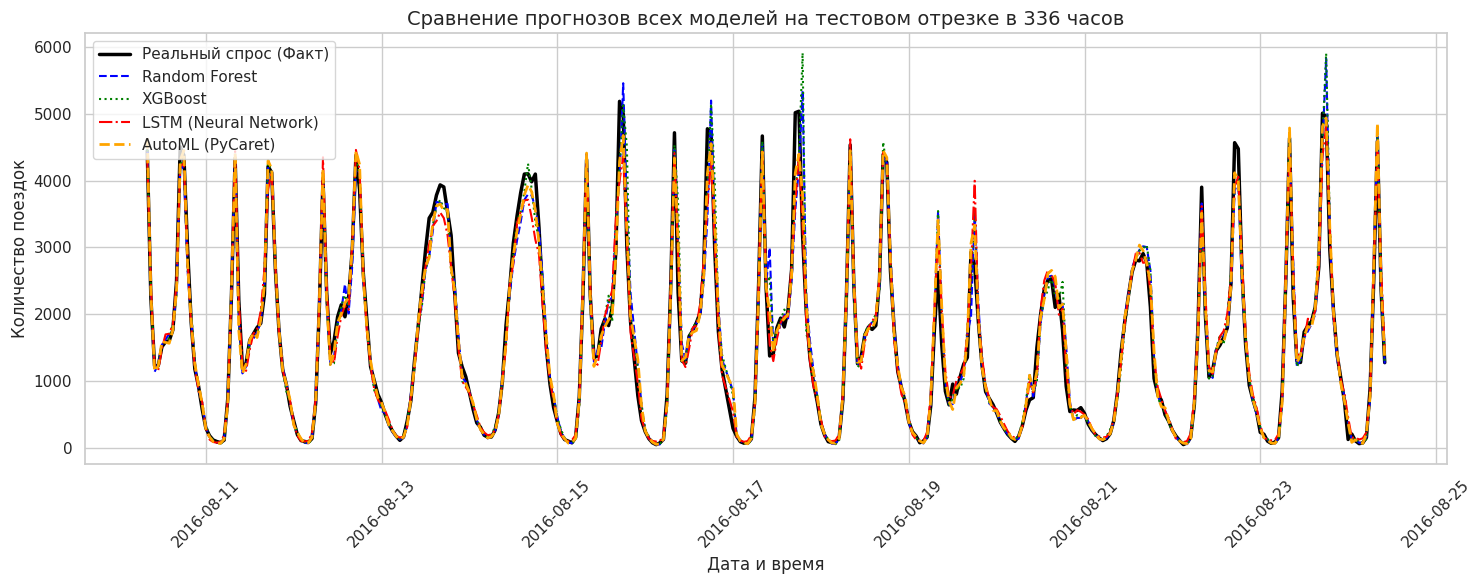

In [41]:
'''
Сравнение предсказаний моделей. График с наложением реального спроса за одну и две недели из тестовой выборки (168 и 336 часов)
'''

# Выберем отрезок из тестовой выборки
subset_len_list = [168, 336]

for subset_len in subset_len_list:
    plt.figure(figsize=(15, 6))
    # Факт
    plt.plot(test_timestamps.iloc[:subset_len], y_test.iloc[:subset_len], color='black', linewidth=2.5, label='Реальный спрос (Факт)')
    # Ручные ML-модели
    plt.plot(test_timestamps.iloc[:subset_len], rf_pred[:subset_len], color='blue', linestyle='--', label='Random Forest')
    plt.plot(test_timestamps.iloc[:subset_len], xgb_pred[:subset_len], color='green', linestyle=':', label='XGBoost')
    # Нейросеть
    plt.plot(test_timestamps.iloc[:subset_len], lstm_pred[:subset_len], color='red', linestyle='-.', label='LSTM (Neural Network)')
    # Лучшая AutoML-модель (оранжевый штрих)
    plt.plot(test_timestamps.iloc[:subset_len], y_pred_automl[:subset_len], color='orange', linestyle='--', linewidth=2, label='AutoML (PyCaret)')

    plt.title(f'Сравнение прогнозов всех моделей на тестовом отрезке в {subset_len} часов', fontsize=14)
    plt.xlabel('Дата и время')
    plt.ylabel('Количество поездок')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()